In [26]:
import numpy as np
from scipy.fft import fft2, ifft2
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.ndimage import gaussian_filter
import yaml
import os

from astropy.io import fits

In [7]:
basedir = f'{os.environ["HOME"]}/projects/debrisdisk_freeform_fit_and_plot'

# Read in config file
default_param_file = "initialization_files/HR4796_i_camsci1_20230309_10.yaml"

param_file_loc = os.path.join(basedir, default_param_file)

# Read in config file
with open(param_file_loc, 'r') as file:
    config = yaml.safe_load(file)


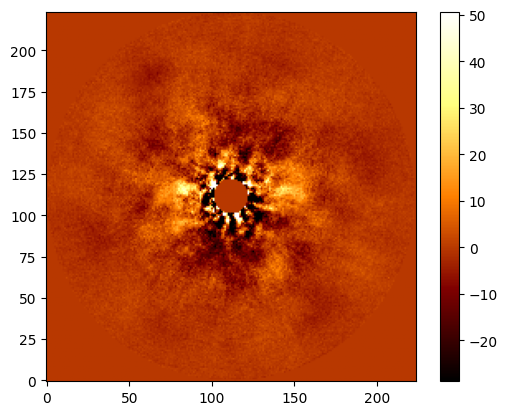

In [ ]:
datadir = config["BAND_DIR"]
file_prefix = config["FILE_PREFIX"]
injected_dir = "/Users/jkueny/data/HR4796a_lco2023a_magao-x_20230309_10/raws_20230310T054736_s_lyot_stop/camsci1/injected_psflib"

klipdir = os.path.join(injected_dir, "klip_fm_files")
resultsdir = os.path.join(injected_dir, "results_freeform")

diskless_image_loc = os.path.join(klipdir, f"{file_prefix}-klipped_counter_rotated.fits")

diskless_image = fits.getdata(diskless_image_loc)
diskless_image[diskless_image != diskless_image] = 0.

if diskless_image.ndim == 3:
    diskless_image = np.squeeze(diskless_image)

diskless_vmin = np.percentile(diskless_image, 0.5)
diskless_vmax = np.percentile(diskless_image, 99.9)

plt.imshow(
    diskless_image, origin="lower", cmap="afmhot",
    vmin=diskless_vmin, vmax=diskless_vmax,
    )
plt.colorbar()
plt.show()


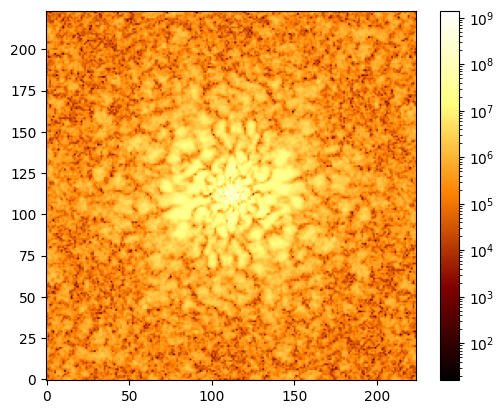

In [27]:
# Compute the diskless image PSD
diskless_psd = np.abs(np.fft.fft2(diskless_image))**2
diskless_psd = np.fft.fftshift(diskless_psd)

plt.imshow(diskless_psd, origin="lower", cmap="afmhot", norm=LogNorm())
plt.colorbar()
plt.show()


In [ ]:
# Read in an example residuals image
